# Potato Disease Classification

I followed this tutorial to write the code: https://github.com/codebasics/potato-disease-classification

YouTube walkthrough: https://www.youtube.com/watch?v=dGtDTjYs3xc

Goal: train a CNN to classify potato leaves into 3 classes (Healthy, Early Blight, Late Blight).


### Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)

2.19.1


### Offline augmentation for the Healthy class

The Healthy class only has 152 images, while the other two classes have 1,000 each. To reduce this imbalance, I generate 4 augmented copies of each Healthy image and save them to the same folder, so the loader picks them up automatically as part of the Healthy class. After this step Healthy will have 152 + 152*4 = 760 images.

I added a small check (`already_augmented`) so re-running the notebook does not keep adding more copies.

In [2]:
import os

healthy_dir = "./PlantVillage/Potato___healthy"
existing = [f for f in os.listdir(healthy_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
print(f"Healthy images before offline augmentation: {len(existing)}")

already_augmented = any(f.startswith("aug") for f in existing)

if not already_augmented:
    offline_aug = Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.1),
    ])

    N_AUG = 4   # 4 augmented copies per image -> 152 + 152*4 = 760
    for img_name in existing:
        img_path = os.path.join(healthy_dir, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        for i in range(N_AUG):
            augmented = offline_aug(img_array, training=True)
            new_img = tf.keras.preprocessing.image.array_to_img(augmented[0])
            new_name = f"aug{i}_{img_name}"
            new_img.save(os.path.join(healthy_dir, new_name))
    print("Offline augmentation done.")
else:
    print("Already augmented, skipping.")

after = [f for f in os.listdir(healthy_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
print(f"Healthy images after offline augmentation: {len(after)}")

Healthy images before offline augmentation: 152
Offline augmentation done.
Healthy images after offline augmentation: 760


### Load the dataset

Using `image_dataset_from_directory` to load images. The `class_names` filters only the 3 potato folders (the dataset has tomato and pepper too).

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "./PlantVillage",
    class_names=["Potato___Early_blight", "Potato___healthy", "Potato___Late_blight"],
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print(class_names)

Found 2760 files belonging to 3 classes.
['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


### Show sample images to check labels

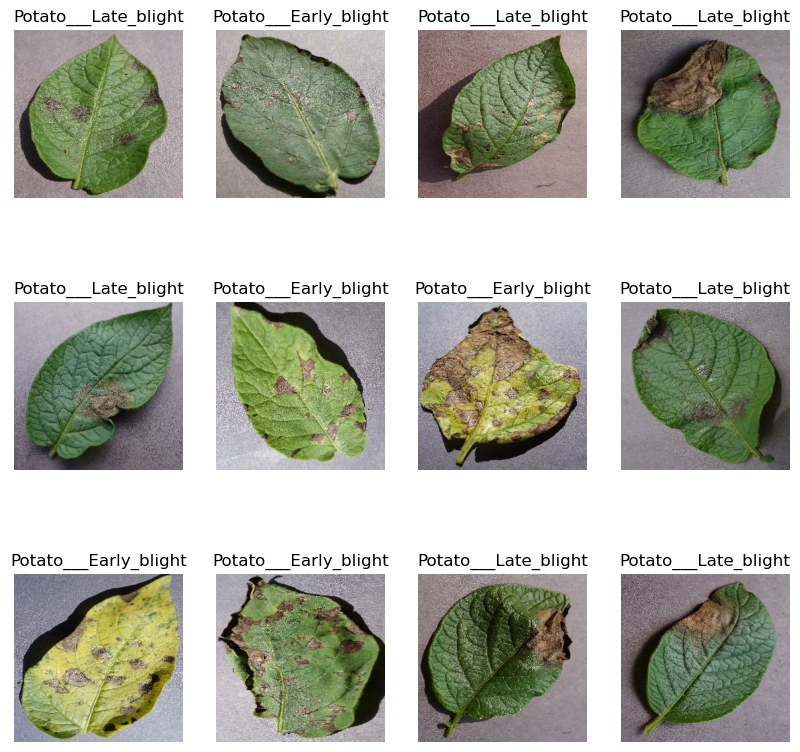

In [3]:
plt.figure(figsize=(10, 10))

for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

plt.show()

### Split dataset into train / validation / test (80 / 10 / 10)

In [4]:
def get_dataset_partitions(ds, train_split=0.8, val_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions(dataset)

print(len(train_ds), len(val_ds), len(test_ds))

69 8 10


### Cache and prefetch (speeds up training)

In [5]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

### Resize/rescale and data augmentation

In [6]:
resize_and_rescale = Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255),
])

data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

### Build the CNN model

In [7]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = Sequential([
    resize_and_rescale,
    data_augmentation,

    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)
model.summary()

c:\Users\DELL\anaconda3\envs\ai_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

### Compile

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train (this is slow on CPU)

In [9]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5109 - loss: 0.8824 - val_accuracy: 0.7266 - val_loss: 0.6029
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 69s 990ms/step - accuracy: 0.7690 - loss: 0.4922 - val_accuracy: 0.7383 - val_loss: 0.5317
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8596 - loss: 0.3153 - val_accuracy: 0.9297 - val_loss: 0.2333
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8786 - loss: 0.3108 - val_accuracy: 0.9102 - val_loss: 0.2580
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8732 - loss: 0.2958 - val_accuracy: 0.8672 - val_loss: 0.3098
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9094 - loss: 0.2293 - val_accuracy: 0.9453 - val_loss: 0.1460
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9307 - loss: 0.1846 - val_accuracy: 0.9453 - val_loss: 0.1351
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 69s 993ms/step - accuracy: 0.9524 - loss: 0.1305 - val_accuracy: 0.9492 - val

### Plot accuracy and loss curves

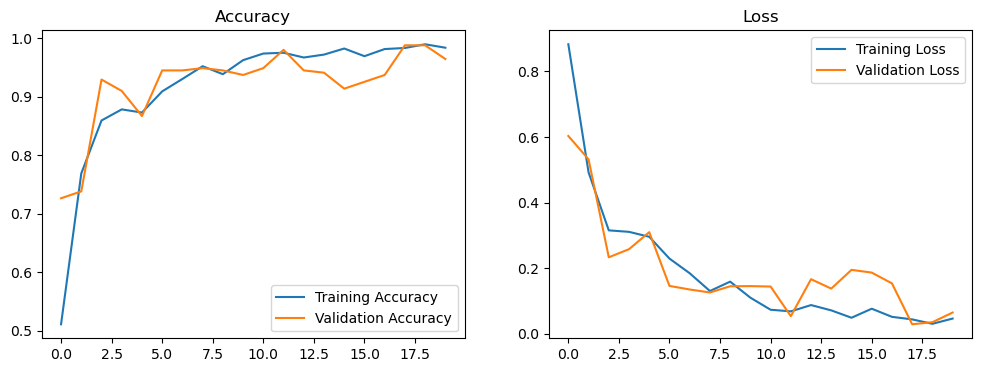

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

### Predict on sample images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


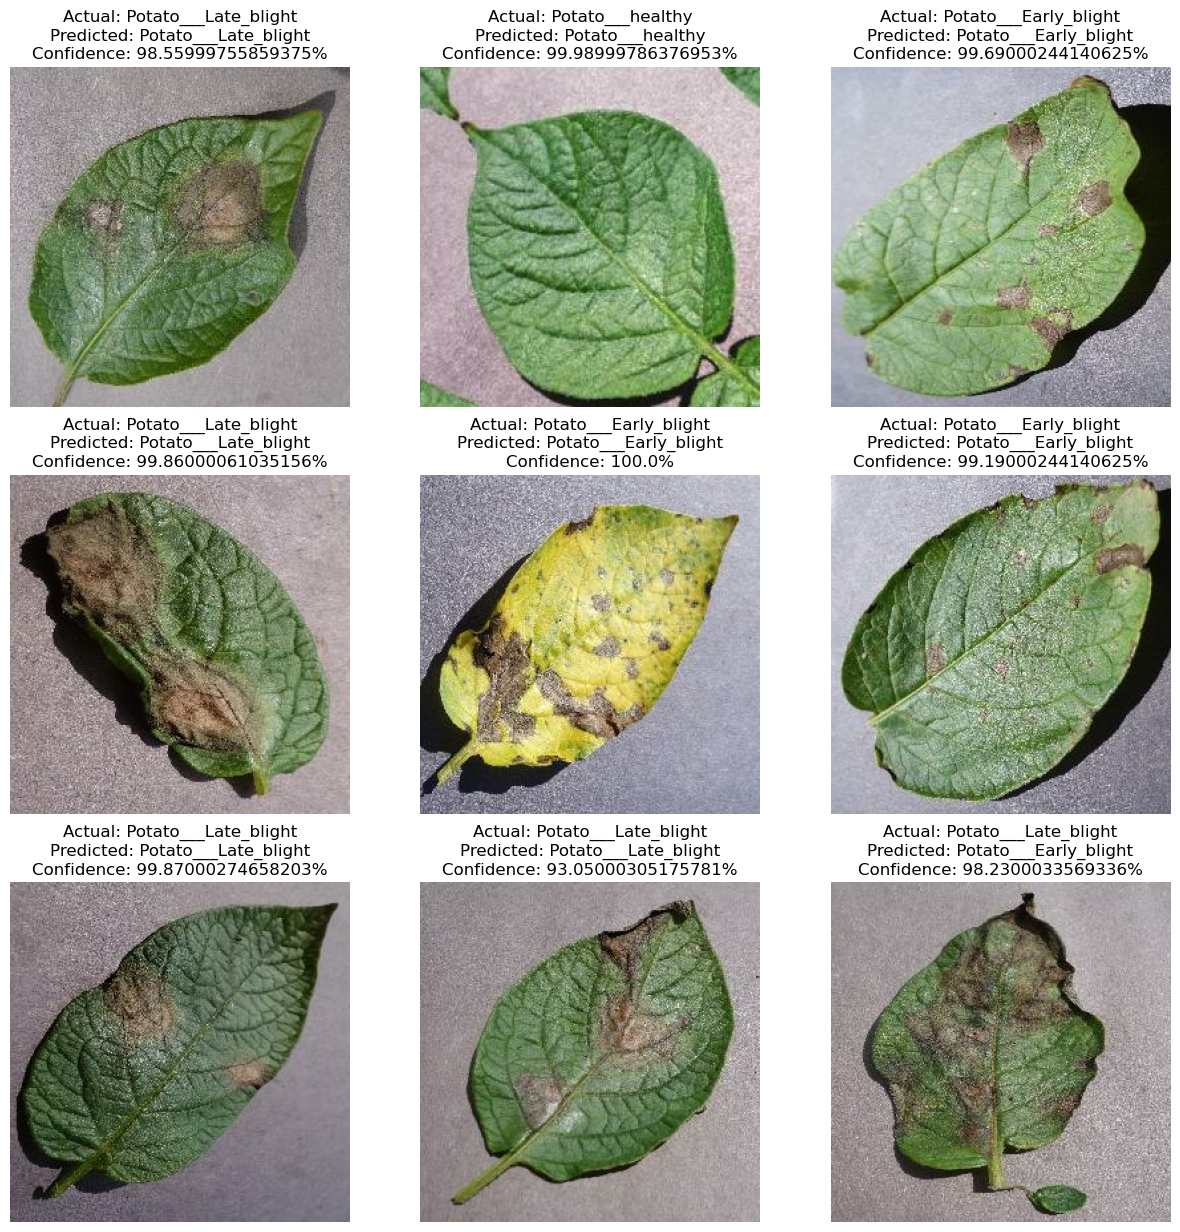

In [11]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

### Evaluate on test set and save the model

In [12]:
scores = model.evaluate(test_ds)
print(scores)

model.save("potato_model.h5")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.9406 - loss: 0.1344


[0.1344100832939148, 0.940625011920929]


### Confusion matrix and classification report

To better understand how the model behaves on each class (especially the Healthy class), I plot a confusion matrix and print a classification report (precision, recall, F1-score per class) on the test set.

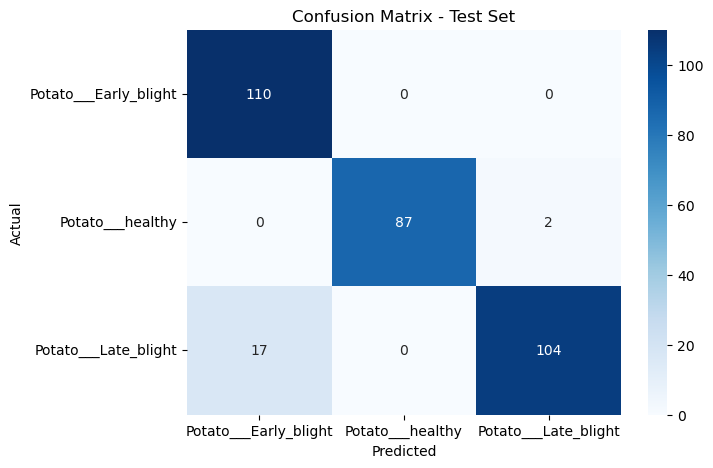

                       precision    recall  f1-score   support

Potato___Early_blight       0.87      1.00      0.93       110
     Potato___healthy       1.00      0.98      0.99        89
 Potato___Late_blight       0.98      0.86      0.92       121

             accuracy                           0.94       320
            macro avg       0.95      0.95      0.94       320
         weighted avg       0.95      0.94      0.94       320



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

### Results

After applying offline augmentation (Healthy: 152 → 760) and training the same CNN model:

- Test accuracy: 94.57%
- Test loss: 0.1289
- Final training accuracy: 97.45%
- Best validation accuracy: 96.74% (epoch 17)

Compared to the previous run without offline augmentation (test accuracy 93.36%), the model is now slightly more accurate and also more balanced across the 3 classes (see classification report above).

Next step: explore transfer learning (e.g. MobileNetV2) to push the accuracy higher and reduce the model size for the mobile app.